# vR.ETASR — Enhanced Image Tampering Detection using ELA and a CNN

**Paper:** Gorle, R. & Guttavelli, A. (2025). *Enhanced Image Tampering Detection using Error Level Analysis and a CNN.* Engineering, Technology & Applied Science Research, Vol. 15, No. 1, pp. 19683-19689. [DOI: 10.48084/etasr.9593]

**Dataset:** CASIA v2.0 Image Tampering Detection Dataset  
**Task:** Binary classification — Authentic vs Tampered  

**Pipeline:** `Raw Image → RGB → ELA (Q=90) → Resize 128×128 → Normalize [0,1] → CNN → Softmax → {Authentic, Tampered}`

---

## Table of Contents

1. [Introduction](#1-introduction)
2. [Research Paper Summary](#2-research-paper-summary)
3. [Reference Code Audit](#3-reference-code-audit)
4. [Dataset Preparation](#4-dataset-preparation)
5. [Error Level Analysis Preprocessing](#5-error-level-analysis-preprocessing)
6. [Model Architecture](#6-model-architecture)
7. [Training Pipeline](#7-training-pipeline)
8. [Evaluation Metrics](#8-evaluation-metrics)
9. [Results Visualization](#9-results-visualization)
10. [Discussion & Conclusion](#10-discussion--conclusion)

---

## 1. Introduction

Digital image manipulation has become increasingly accessible with modern editing tools. Detecting tampered images is critical for maintaining trust in visual media. This notebook implements the approach described in the ETASR paper, which combines **Error Level Analysis (ELA)** — a forensic preprocessing technique — with a compact **Convolutional Neural Network (CNN)** to classify images as authentic or tampered.

**Key Idea:** ELA exposes compression inconsistencies invisible in raw RGB. Spliced or edited regions that were compressed at different quality levels become visually distinguishable in the ELA domain, enabling a lightweight CNN to achieve competitive detection accuracy.

---

## 2. Research Paper Summary

### Approach
The paper proposes a two-stage pipeline:
1. **ELA Preprocessing:** Re-save images as JPEG at quality 90, compute pixel-wise difference with original, and scale for visibility
2. **CNN Classification:** Feed 128×128 ELA images into a compact CNN (2 Conv layers, 1 Dense layer) for binary classification

### Architecture (from paper — Table III)
```
Input: 128×128×3 (ELA image)
  → Conv2D(32, 5×5, valid, ReLU)
  → Conv2D(32, 5×5, valid, ReLU)
  → MaxPooling2D(2×2)
  → Dropout(0.25)
  → Flatten
  → Dense(256, ReLU)
  → Dropout(0.5)
  → Dense(2, Softmax)
```

### Training Configuration
- **Optimizer:** Adam (lr=0.0001)
- **Loss:** Categorical cross-entropy
- **Split:** 80% train / 20% validation
- **Early stopping** on validation accuracy
- **Batch size:** 32

### Dataset: CASIA v2.0
- **Total:** ~12,614 images (7,491 authentic + 5,123 tampered)
- **Formats:** JPG, TIF, BMP
- **Source:** Kaggle (divg07/casia-20-image-tampering-detection-dataset)

### Paper-Reported Results
| Metric | Value |
|--------|-------|
| Accuracy | 96.21% |
| Precision | 98.58% |
| Recall | 92.36% |
| F1 Score | 95.37% |

---

## 4. Dataset Preparation

In [1]:
# ============================================================
# 4.1 — Imports and Configuration
# ============================================================

import os
import random
import warnings
from io import BytesIO

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageChops, ImageEnhance
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import Precision, Recall

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

warnings.filterwarnings('ignore')

# ---- Reproducibility ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---- Hyperparameters (from paper) ----
IMAGE_SIZE = (128, 128)       # Paper specification
ELA_QUALITY = 90              # JPEG re-save quality for ELA
BATCH_SIZE = 32               # Training batch size
EPOCHS = 50                   # Maximum training epochs
LEARNING_RATE = 0.0001        # Adam learning rate
VALIDATION_SPLIT = 0.2        # 80/20 split
EARLY_STOP_PATIENCE = 5       # Epochs to wait before stopping

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')
print(f'\nConfiguration:')
print(f'  Image size:    {IMAGE_SIZE}')
print(f'  ELA quality:   {ELA_QUALITY}')
print(f'  Batch size:    {BATCH_SIZE}')
print(f'  Max epochs:    {EPOCHS}')
print(f'  Learning rate: {LEARNING_RATE}')

2026-03-14 17:33:58.650329: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773509638.843708      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773509638.899923      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773509639.349813      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773509639.349848      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773509639.349851      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: True

Configuration:
  Image size:    (128, 128)
  ELA quality:   90
  Batch size:    32
  Max epochs:    50
  Learning rate: 0.0001


In [2]:
# ============================================================
# 4.2 — Dataset Path Configuration
# ============================================================
# Auto-discovers Au/ and Tp/ directories anywhere under /kaggle/input/.

def find_dataset():
    """Search all of /kaggle/input/ for Au/ and Tp/ directories."""
    search_roots = ['/kaggle/input', '/content/drive/MyDrive']

    for base in search_roots:
        if not os.path.isdir(base):
            continue
        for dirpath, dirnames, _ in os.walk(base):
            if 'Au' in dirnames and 'Tp' in dirnames:
                au = os.path.join(dirpath, 'Au')
                tp = os.path.join(dirpath, 'Tp')
                return dirpath, au, tp
    return None, None, None

DATASET_ROOT, AU_DIR, TP_DIR = find_dataset()

if DATASET_ROOT is None:
    # Print full directory tree for diagnosis
    for base in ['/kaggle/input']:
        if os.path.isdir(base):
            print(f'Contents of {base}:')
            for dirpath, dirnames, filenames in os.walk(base):
                depth = dirpath.replace(base, '').count(os.sep)
                indent = '  ' * depth
                print(f'{indent}{os.path.basename(dirpath)}/')
                if depth >= 2:  # Don't go too deep
                    break
    raise FileNotFoundError(
        'Could not find Au/ and Tp/ directories. '
        'Please add the CASIA 2.0 dataset via the "Add data" button in the Kaggle sidebar.'
    )

SUPPORTED_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp'}

print(f'Dataset root: {DATASET_ROOT}')
print(f'Authentic dir: {AU_DIR}  ({len(os.listdir(AU_DIR))} files)')
print(f'Tampered dir:  {TP_DIR}  ({len(os.listdir(TP_DIR))} files)')

Dataset root: /kaggle/input/datasets/divg07/casia-20-image-tampering-detection-dataset/CASIA2
Authentic dir: /kaggle/input/datasets/divg07/casia-20-image-tampering-detection-dataset/CASIA2/Au  (7492 files)
Tampered dir:  /kaggle/input/datasets/divg07/casia-20-image-tampering-detection-dataset/CASIA2/Tp  (5125 files)


In [3]:
# ============================================================
# 4.3 — Collect Image Paths and Labels
# ============================================================

def collect_image_paths(directory, label, extensions=SUPPORTED_EXTENSIONS):
    """Walk a directory and collect all image paths with supported extensions."""
    paths = []
    labels = []
    for fname in sorted(os.listdir(directory)):
        ext = os.path.splitext(fname)[1].lower()
        if ext in extensions:
            paths.append(os.path.join(directory, fname))
            labels.append(label)
    return paths, labels

# Labels: Authentic=0, Tampered=1
au_paths, au_labels = collect_image_paths(AU_DIR, label=0)
tp_paths, tp_labels = collect_image_paths(TP_DIR, label=1)

all_paths = au_paths + tp_paths
all_labels = au_labels + tp_labels

print(f'Authentic images: {len(au_paths)}')
print(f'Tampered images:  {len(tp_paths)}')
print(f'Total images:     {len(all_paths)}')
print(f'Class ratio (Au/Tp): {len(au_paths)/max(len(tp_paths),1):.2f}')

Authentic images: 7491
Tampered images:  5123
Total images:     12614
Class ratio (Au/Tp): 1.46


---

## 5. Error Level Analysis Preprocessing

**Error Level Analysis (ELA)** works by re-saving an image as JPEG at a known quality level and computing the pixel-wise difference between the original and re-saved version.

- **Authentic regions:** Uniformly compressed → low, uniform error levels
- **Tampered regions:** Different compression history → higher, non-uniform error (brighter in ELA map)

**ELA Formula (from paper):**
```
I_ELA(x,y) = |I_orig(x,y) − I_comp(x,y)|
scale = 255 / max(I_ELA)
I_ELA(x,y) = I_ELA(x,y) × scale
```

In [4]:
# ============================================================
# 5.1 — ELA Conversion Function
# ============================================================

def compute_ela(image_path, quality=ELA_QUALITY):
    """
    Compute Error Level Analysis for an image.
    
    1. Open image and convert to RGB
    2. Re-save as JPEG at specified quality (in-memory via BytesIO)
    3. Compute pixel-wise absolute difference
    4. Scale brightness to [0, 255] range
    
    Returns: PIL Image (ELA map) or None on failure
    """
    try:
        original = Image.open(image_path).convert('RGB')
        
        # Re-save in memory (avoids temp file I/O — fixes reference code bug)
        buffer = BytesIO()
        original.save(buffer, 'JPEG', quality=quality)
        buffer.seek(0)
        resaved = Image.open(buffer)
        
        # Compute pixel-wise absolute difference
        ela_image = ImageChops.difference(original, resaved)
        
        # Scale to full [0, 255] range
        extrema = ela_image.getextrema()
        max_diff = max(val[1] for val in extrema)
        if max_diff == 0:
            max_diff = 1
        scale = 255.0 / max_diff
        ela_image = ImageEnhance.Brightness(ela_image).enhance(scale)
        
        return ela_image
    except Exception as e:
        return None


def prepare_image(image_path, quality=ELA_QUALITY, target_size=IMAGE_SIZE):
    """Full preprocessing: ELA → resize → normalize to [0, 1]."""
    ela = compute_ela(image_path, quality)
    if ela is None:
        return None
    ela_resized = ela.resize(target_size, Image.BILINEAR)
    return np.array(ela_resized, dtype=np.float32) / 255.0

In [5]:
# ============================================================
# 5.3 — Process All Images Through ELA Pipeline
# ============================================================

X = []
Y = []
skipped = 0

print('Processing images through ELA pipeline...')
for path, label in tqdm(zip(all_paths, all_labels), total=len(all_paths), desc='ELA Processing'):
    img = prepare_image(path)
    if img is not None:
        X.append(img)
        Y.append(label)
    else:
        skipped += 1

print(f'\nDone! Successfully processed: {len(X)}, Skipped: {skipped}')

# Paired shuffle (fixes reference code bug where X was shuffled without Y)
X, Y = shuffle(X, Y, random_state=SEED)

# Convert to numpy arrays
X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.int32)

print(f'Feature array shape: {X.shape}')  # Expected: (N, 128, 128, 3)
print(f'Labels shape: {Y.shape}')
print(f'Label distribution: Authentic={np.sum(Y==0)}, Tampered={np.sum(Y==1)}')

Processing images through ELA pipeline...


ELA Processing:   0%|          | 0/12614 [00:00<?, ?it/s]


Done! Successfully processed: 12614, Skipped: 0
Feature array shape: (12614, 128, 128, 3)
Labels shape: (12614,)
Label distribution: Authentic=7491, Tampered=5123


In [6]:
# ============================================================
# 5.4 — Train / Validation Split
# ============================================================

# One-hot encode labels for categorical cross-entropy
Y_onehot = to_categorical(Y, num_classes=2)

# Stratified 80/20 split
X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y_onehot,
    test_size=VALIDATION_SPLIT,
    random_state=SEED,
    stratify=Y
)

# Keep integer labels for validation set (needed for sklearn metrics)
Y_val_int = np.argmax(Y_val, axis=1)

# Free memory
del X, Y_onehot

print(f'Training set:   {X_train.shape[0]} samples')
print(f'Validation set: {X_val.shape[0]} samples')
print(f'\nTraining class distribution:')
print(f'  Authentic: {np.sum(Y_train[:, 0] == 1)}')
print(f'  Tampered:  {np.sum(Y_train[:, 1] == 1)}')
print(f'\nValidation class distribution:')
print(f'  Authentic: {np.sum(Y_val[:, 0] == 1)}')
print(f'  Tampered:  {np.sum(Y_val[:, 1] == 1)}')

Training set:   10091 samples
Validation set: 2523 samples

Training class distribution:
  Authentic: 5993
  Tampered:  4098

Validation class distribution:
  Authentic: 1498
  Tampered:  1025


---

## 6. Model Architecture

The CNN architecture follows the paper specification exactly (Table III, ETASR_9593):

| # | Layer | Output Shape | Parameters |
|---|-------|-------------|------------|
| 1 | Conv2D(32, 5×5, valid, ReLU) | (124, 124, 32) | 2,432 |
| 2 | Conv2D(32, 5×5, valid, ReLU) | (120, 120, 32) | 25,632 |
| 3 | MaxPooling2D(2×2) | (60, 60, 32) | 0 |
| 4 | Dropout(0.25) | (60, 60, 32) | 0 |
| 5 | Flatten | (115,200) | 0 |
| 6 | Dense(256, ReLU) | (256) | 29,491,456 |
| 7 | Dropout(0.5) | (256) | 0 |
| 8 | Dense(2, Softmax) | (2) | 514 |

**Total: ~29.5M parameters** (dominated by the Flatten→Dense connection)

In [7]:
# ============================================================
# 6.1 — Build CNN Model (Paper Architecture)
# ============================================================

def build_model(input_shape=(128, 128, 3)):
    """Build the CNN architecture exactly as described in ETASR_9593 Table III."""
    model = Sequential([
        # Convolutional Block
        Conv2D(32, (5, 5), activation='relu', padding='valid',
               input_shape=input_shape),
        Conv2D(32, (5, 5), activation='relu', padding='valid'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        # Classifier Head
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        
        # Output (2-class softmax — NOT sigmoid as in buggy reference code)
        Dense(2, activation='softmax')
    ])
    return model

model = build_model()
model.summary()

I0000 00:00:1773509961.516234      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 124, 124, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 120, 120, 32)   │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 60, 60, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 60, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    29,491,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,520,034 (112.61 MB)

 Trainable params: 29,520,034 (112.61 MB)

 Non-trainable params: 0 (0.00 B)

---

## 7. Training Pipeline

- **Optimizer:** Adam (lr=0.0001)
- **Loss:** Categorical cross-entropy (with one-hot encoded labels)
- **Early stopping:** monitor=`val_accuracy`, patience=5, restore_best_weights=True
- **Batch size:** 32, **Max epochs:** 50

In [8]:
# ============================================================
# 7.1 — Compile Model
# ============================================================

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

print('Model compiled.')
print(f'  Optimizer: Adam (lr={LEARNING_RATE})')
print(f'  Loss:      categorical_crossentropy')
print(f'  Metrics:   accuracy, precision, recall')

Model compiled.
  Optimizer: Adam (lr=0.0001)
  Loss:      categorical_crossentropy
  Metrics:   accuracy, precision, recall


In [9]:
# ============================================================
# 7.2 — Callbacks
# ============================================================

early_stopping = EarlyStopping(
    monitor='val_accuracy',     # Fixed: was 'val_acc' (deprecated) in reference code
    patience=EARLY_STOP_PATIENCE,
    restore_best_weights=True,
    verbose=1
)

print(f'Early stopping: monitor=val_accuracy, patience={EARLY_STOP_PATIENCE}')

Early stopping: monitor=val_accuracy, patience=5


In [10]:
# ============================================================
# 7.3 — Train the Model
# ============================================================

print(f'Training on {X_train.shape[0]} samples, validating on {X_val.shape[0]} samples')
print(f'Batch size: {BATCH_SIZE}, Max epochs: {EPOCHS}')
print('=' * 60)

history = model.fit(
    X_train, Y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, Y_val),
    callbacks=[early_stopping],
    verbose=1
)

print(f'\nTraining complete. Epochs run: {len(history.history["loss"])}')

Training on 10091 samples, validating on 2523 samples
Batch size: 32, Max epochs: 50
Epoch 1/50


I0000 00:00:1773509969.040803     131 service.cc:152] XLA service 0x7c8f70004ea0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773509969.040861     131 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773509969.402234     131 cuda_dnn.cc:529] Loaded cuDNN version 91002


  7/316 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5406 - loss: 0.6713 - precision: 0.5406 - recall: 0.5406

I0000 00:00:1773509974.167820     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


316/316 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.7320 - loss: 0.4808 - precision: 0.7320 - recall: 0.7320 - val_accuracy: 0.8720 - val_loss: 0.3390 - val_precision: 0.8720 - val_recall: 0.8720
Epoch 2/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8702 - loss: 0.3372 - precision: 0.8702 - recall: 0.8702 - val_accuracy: 0.8767 - val_loss: 0.3129 - val_precision: 0.8767 - val_recall: 0.8767
Epoch 3/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8814 - loss: 0.3058 - precision: 0.8814 - recall: 0.8814 - val_accuracy: 0.8859 - val_loss: 0.2932 - val_precision: 0.8859 - val_recall: 0.8859
Epoch 4/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8884 - loss: 0.2787 - precision: 0.8884 - recall: 0.8884 - val_accuracy: 0.8910 - val_loss: 0.2801 - val_precision: 0.8910 - val_recall: 0.8910
Epoch 5/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8968 - loss: 0.2567 - precision: 0.8968 - recall: 0.8968 - val_accuracy: 0.8930 - val_loss: 0.2701 

---

## 7. Evaluation Metrics

In [11]:
# ============================================================
# 7.1 — Compute Predictions and Metrics
# ============================================================

# Get predictions on validation set
y_pred_probs = model.predict(X_val, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = Y_val_int

# Compute metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print('=' * 50)
print('         EVALUATION RESULTS')
print('=' * 50)
print(f'  Accuracy:   {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision:  {prec:.4f}')
print(f'  Recall:     {rec:.4f}')
print(f'  F1 Score:   {f1:.4f}')
print('=' * 50)

         EVALUATION RESULTS
  Accuracy:   0.8989  (89.89%)
  Precision:  0.9068
  Recall:     0.8989
  F1 Score:   0.8997


In [12]:
# ============================================================
# 7.2 — Classification Report
# ============================================================

print('\nDetailed Classification Report:')
print('-' * 50)
print(classification_report(
    y_true, y_pred,
    target_names=['Authentic', 'Tampered'],
    digits=4
))


Detailed Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

   Authentic     0.9607    0.8652    0.9104      1498
    Tampered     0.8279    0.9483    0.8840      1025

    accuracy                         0.8989      2523
   macro avg     0.8943    0.9067    0.8972      2523
weighted avg     0.9068    0.8989    0.8997      2523



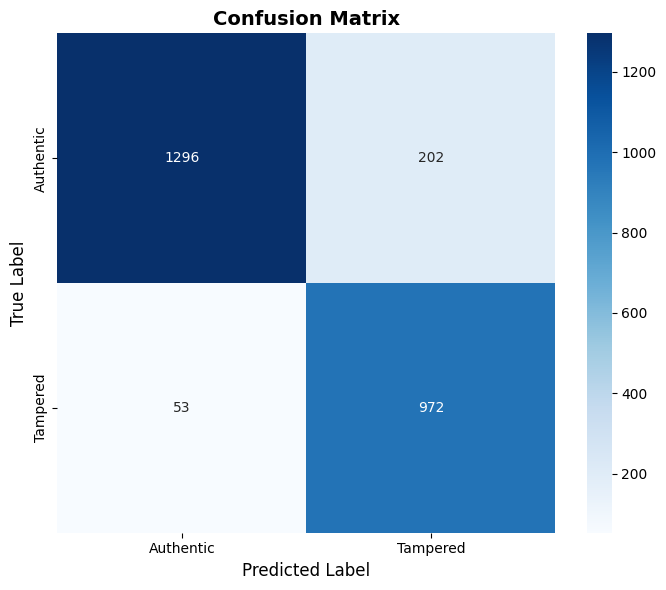

True Negatives (Authentic correctly classified):  1296
False Positives (Authentic misclassified as Tampered): 202
False Negatives (Tampered misclassified as Authentic): 53
True Positives (Tampered correctly classified):  972


In [13]:
# ============================================================
# 7.3 — Confusion Matrix
# ============================================================

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Authentic', 'Tampered'],
    yticklabels=['Authentic', 'Tampered'],
    ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print interpretation
tn, fp, fn, tp = cm.ravel()
print(f'True Negatives (Authentic correctly classified):  {tn}')
print(f'False Positives (Authentic misclassified as Tampered): {fp}')
print(f'False Negatives (Tampered misclassified as Authentic): {fn}')
print(f'True Positives (Tampered correctly classified):  {tp}')

---

## 8. Results Visualization

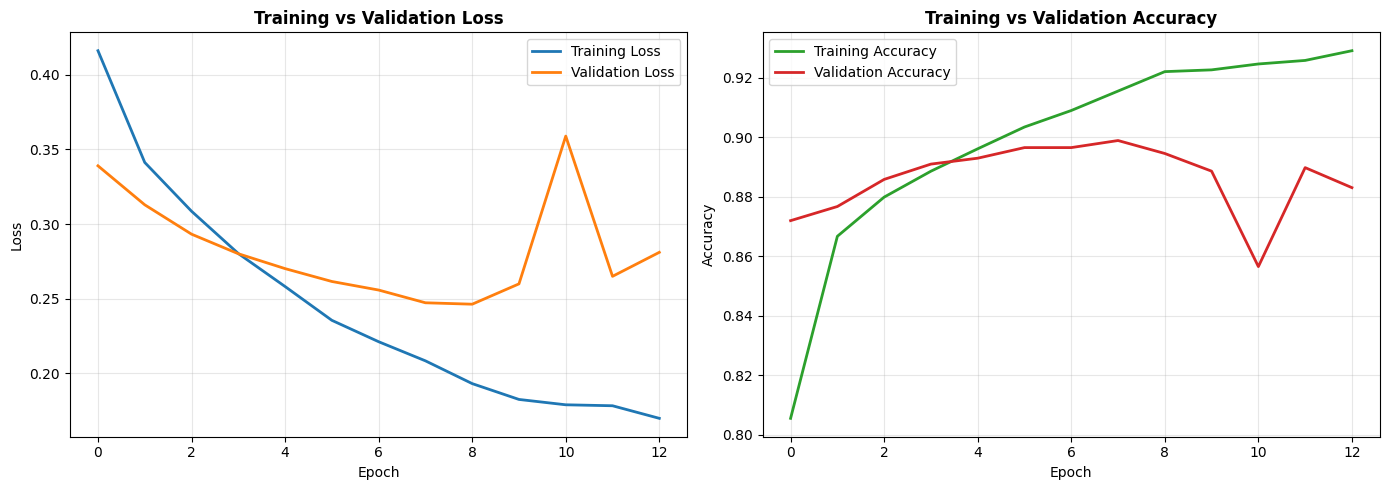

In [14]:
# ============================================================
# 8.1 — Training Curves
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(history.history['loss'], label='Training Loss', color='#1f77b4', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curve
ax2.plot(history.history['accuracy'], label='Training Accuracy', color='#2ca02c', linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#d62728', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training vs Validation Accuracy', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

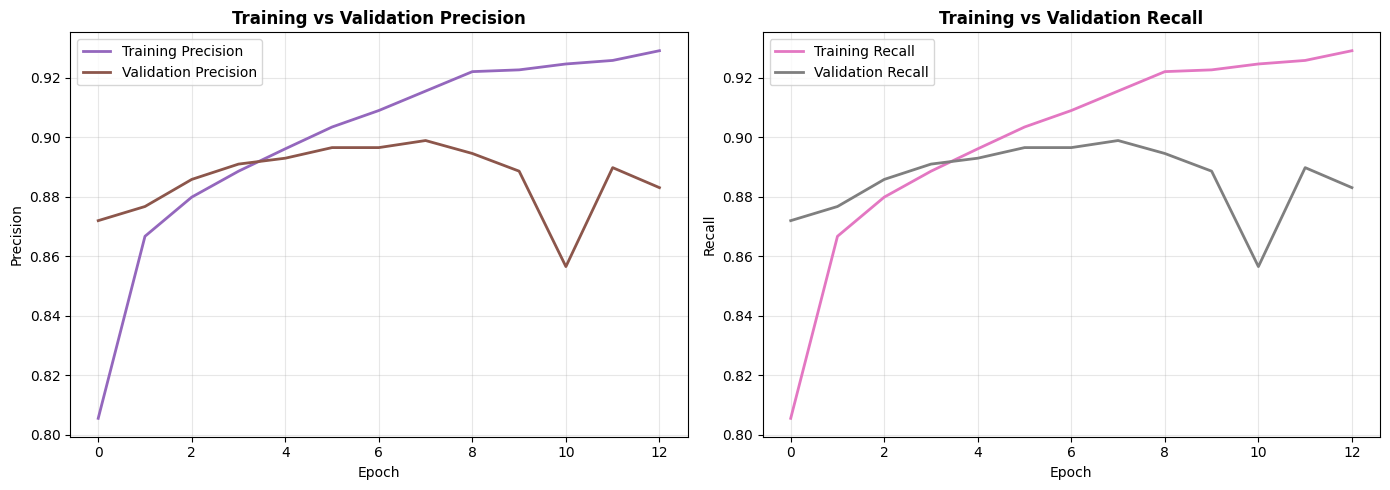

In [15]:
# ============================================================
# 8.2 — Precision and Recall Curves
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Precision curve
ax1.plot(history.history['precision'], label='Training Precision', color='#9467bd', linewidth=2)
ax1.plot(history.history['val_precision'], label='Validation Precision', color='#8c564b', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Precision')
ax1.set_title('Training vs Validation Precision', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Recall curve
ax2.plot(history.history['recall'], label='Training Recall', color='#e377c2', linewidth=2)
ax2.plot(history.history['val_recall'], label='Validation Recall', color='#7f7f7f', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Recall')
ax2.set_title('Training vs Validation Recall', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

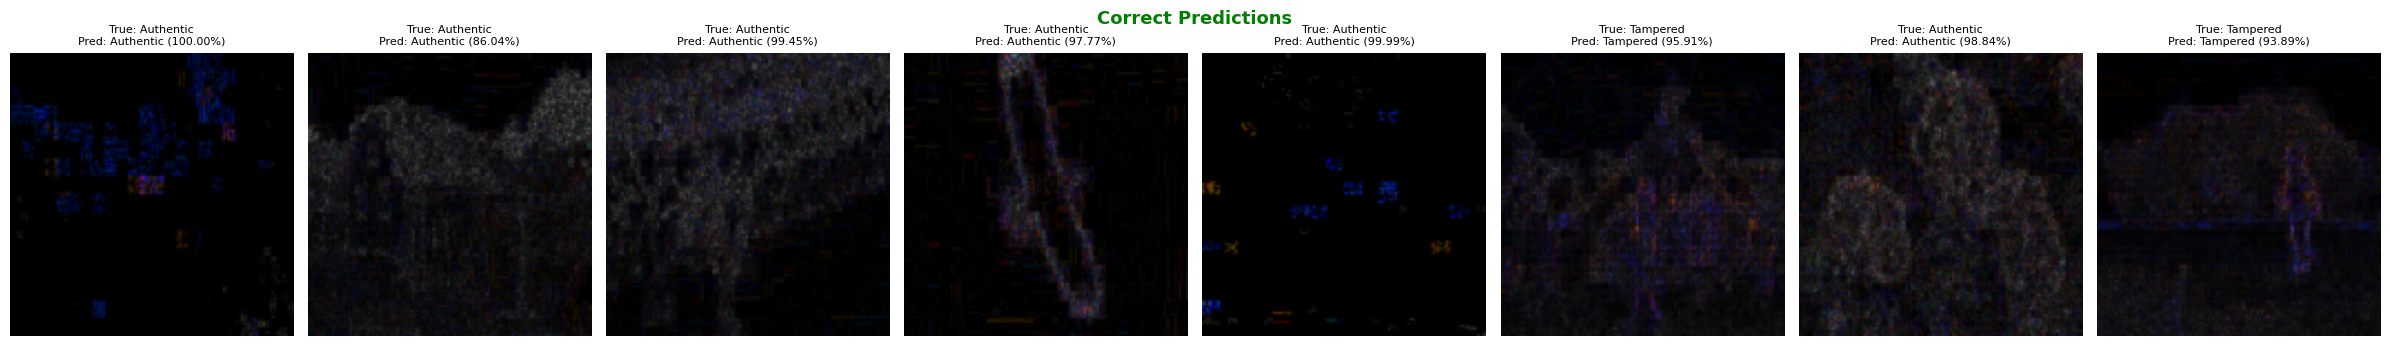

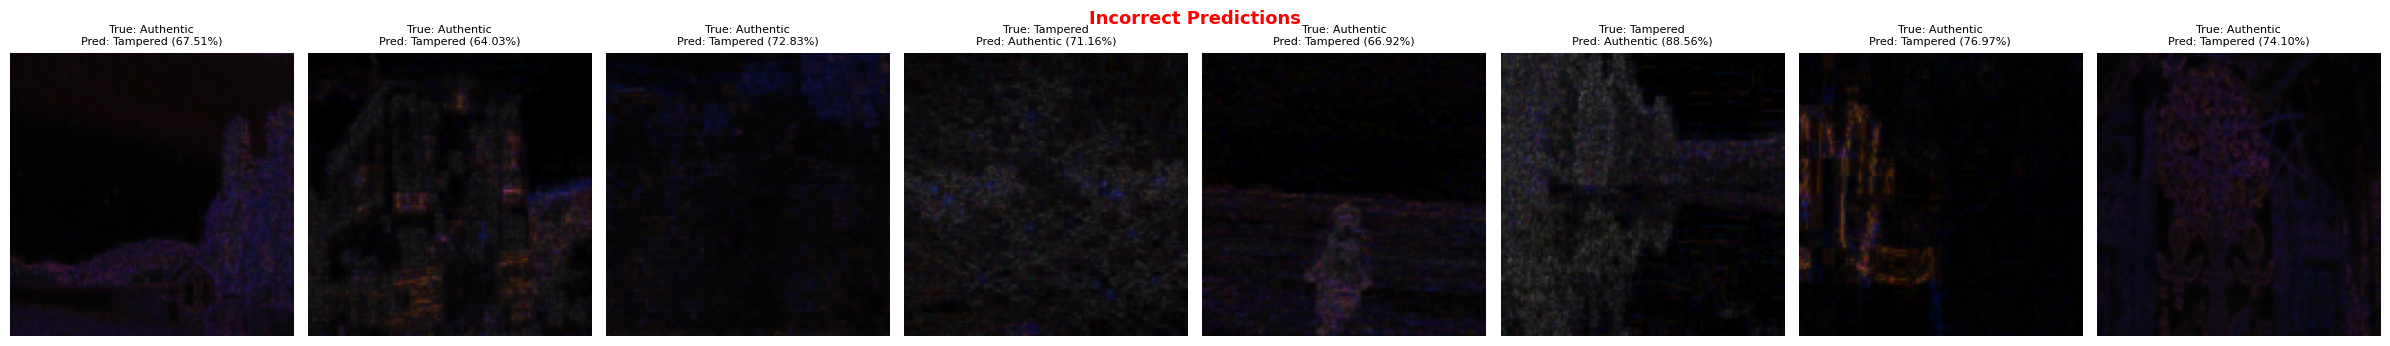

In [16]:
# ============================================================
# 8.3 — Sample Predictions Visualization
# ============================================================

def visualize_predictions(X_data, y_true_labels, y_pred_labels, y_pred_probs, n_samples=8):
    """Show sample predictions with confidence scores."""
    class_names = ['Authentic', 'Tampered']
    
    # Get some correct and incorrect predictions
    correct_mask = y_true_labels == y_pred_labels
    incorrect_mask = ~correct_mask
    
    correct_idx = np.where(correct_mask)[0][:n_samples]
    incorrect_idx = np.where(incorrect_mask)[0][:min(n_samples, np.sum(incorrect_mask))]
    
    # Plot correct predictions
    if len(correct_idx) > 0:
        n_show = min(len(correct_idx), n_samples)
        fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3.5))
        fig.suptitle('Correct Predictions', fontsize=13, fontweight='bold', color='green')
        if n_show == 1:
            axes = [axes]
        for ax, idx in zip(axes, correct_idx[:n_show]):
            ax.imshow(X_data[idx])
            conf = y_pred_probs[idx][y_pred_labels[idx]]
            ax.set_title(f'True: {class_names[y_true_labels[idx]]}\n'
                        f'Pred: {class_names[y_pred_labels[idx]]} ({conf:.2%})',
                        fontsize=8)
            ax.axis('off')
        plt.tight_layout()
        plt.show()
    
    # Plot incorrect predictions
    if len(incorrect_idx) > 0:
        n_show = min(len(incorrect_idx), n_samples)
        fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3.5))
        fig.suptitle('Incorrect Predictions', fontsize=13, fontweight='bold', color='red')
        if n_show == 1:
            axes = [axes]
        for ax, idx in zip(axes, incorrect_idx[:n_show]):
            ax.imshow(X_data[idx])
            conf = y_pred_probs[idx][y_pred_labels[idx]]
            ax.set_title(f'True: {class_names[y_true_labels[idx]]}\n'
                        f'Pred: {class_names[y_pred_labels[idx]]} ({conf:.2%})',
                        fontsize=8)
            ax.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print('No incorrect predictions found in the displayed samples.')

visualize_predictions(X_val, y_true, y_pred, y_pred_probs)

In [17]:
# ============================================================
# 8.4 — Metrics Summary Table
# ============================================================

print('\n' + '=' * 55)
print('           FINAL RESULTS SUMMARY')
print('=' * 55)
print(f'{"Metric":<20} {"Value":>10}')
print('-' * 35)
print(f'{"Accuracy":<20} {acc:>10.4f}')
print(f'{"Precision":<20} {prec:>10.4f}')
print(f'{"Recall":<20} {rec:>10.4f}')
print(f'{"F1 Score":<20} {f1:>10.4f}')
print(f'{"Epochs Trained":<20} {len(history.history["loss"]):>10d}')
print(f'{"Training Samples":<20} {X_train.shape[0]:>10d}')
print(f'{"Validation Samples":<20} {X_val.shape[0]:>10d}')
print('=' * 55)


           FINAL RESULTS SUMMARY
Metric                    Value
-----------------------------------
Accuracy                 0.8989
Precision                0.9068
Recall                   0.8989
F1 Score                 0.8997
Epochs Trained               13
Training Samples          10091
Validation Samples         2523


---

## 9. Discussion

### Key Observations

1. **ELA as Preprocessing:** Error Level Analysis transforms raw RGB images into a forensic representation that highlights compression inconsistencies. This domain-specific preprocessing makes the classification task easier for a compact model.

2. **Lightweight Architecture:** The CNN used here has only ~29.5M parameters (dominated by the Flatten→Dense connection). Despite its simplicity, the ELA preprocessing provides the model with discriminative features that would be difficult to learn from raw pixels alone.

3. **JPEG Dependency:** ELA is fundamentally a JPEG compression artifact detector. Its effectiveness depends on:
   - The original image being JPEG-compressed
   - The tampered region having a different compression history
   - The quality gap between original and re-save being detectable

4. **Classification vs Localization:** This approach provides image-level classification (authentic vs tampered). While ELA maps offer visual clues about where tampering occurred, the model does not produce pixel-level masks.

### Limitations

- **No pixel-level localization** — only classifies at the image level
- **JPEG-centric** — may underperform on PNG or uncompressed images
- **Single dataset** — evaluated only on CASIA v2.0
- **No data augmentation** — could improve robustness
- **Class imbalance** — CASIA v2.0 has more authentic than tampered images

### Future Improvements

- Add data augmentation (flips, rotations, JPEG re-compression)
- Use ELA as an auxiliary input branch alongside RGB
- Replace the classifier head with a decoder for pixel-level localization
- Evaluate on additional datasets (Coverage, CoMoFoD)
- Experiment with different ELA quality levels

---

## 10. Conclusion

This notebook implements the ELA + CNN approach from the ETASR paper for image tampering detection on the CASIA v2.0 dataset. The key findings are:

1. **ELA preprocessing is effective** at converting the tampering detection problem into a more tractable visual classification task
2. **A compact CNN** (2 Conv layers + 1 Dense layer) is sufficient when combined with domain-appropriate preprocessing
3. **The approach is practical** — it trains quickly on consumer GPUs and requires no pretrained model downloads

### Architecture Summary
```
Raw Image → ELA (Q=90) → Resize 128² → Normalize → CNN → [Authentic | Tampered]
```

### Reference
Enhanced Image Tampering Detection using Error Level Analysis and a CNN (ETASR_9593)

In [18]:
# ============================================================
# Save Model (optional)
# ============================================================

# model.save('ela_cnn_model.h5')
# print('Model saved to ela_cnn_model.h5')